# Robot Arm Kinematics and Control

This notebook explores the mathematics behind robot arm movement, covering:

1. **Forward Kinematics**: Given joint angles, compute end-effector position
2. **Inverse Kinematics**: Given desired position, compute joint angles
3. **Jacobian Matrix**: Relate joint velocities to end-effector velocities
4. **Trajectory Planning**: Generate smooth paths for robot motion

We'll implement a 2-link planar robot arm and visualize its workspace and trajectories.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 11

# Notebook directory for saving plots
NOTEBOOK_DIR = '/home/user/computational-pipeline/notebooks/published/robot_kinematics'

print(f"Notebook directory: {NOTEBOOK_DIR}")
print("Libraries loaded successfully!")

Notebook directory: /home/user/computational-pipeline/notebooks/published/robot_kinematics
Libraries loaded successfully!


## 1. Robot Arm Model

We model a **2-link planar robot arm** (2R robot):
- Link 1: length $L_1$, angle $\theta_1$ (from horizontal)
- Link 2: length $L_2$, angle $\theta_2$ (relative to Link 1)

### Forward Kinematics

The end-effector position $(x, y)$ given joint angles $(\theta_1, \theta_2)$:

$$x = L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2)$$
$$y = L_1 \sin(\theta_1) + L_2 \sin(\theta_1 + \theta_2)$$

In [2]:
class TwoLinkArm:
    """2-link planar robot arm with forward and inverse kinematics"""
    
    def __init__(self, L1=1.0, L2=0.8):
        """
        Initialize robot arm with link lengths.
        
        Parameters:
        - L1: Length of first link (shoulder to elbow)
        - L2: Length of second link (elbow to end-effector)
        """
        self.L1 = L1
        self.L2 = L2
        self.theta1 = 0.0  # Joint 1 angle (radians)
        self.theta2 = 0.0  # Joint 2 angle (radians)
    
    def forward_kinematics(self, theta1, theta2):
        """
        Compute end-effector position from joint angles.
        
        Returns: (x, y) position of end-effector
        """
        # Elbow position
        x1 = self.L1 * np.cos(theta1)
        y1 = self.L1 * np.sin(theta1)
        
        # End-effector position
        x2 = x1 + self.L2 * np.cos(theta1 + theta2)
        y2 = y1 + self.L2 * np.sin(theta1 + theta2)
        
        return x2, y2
    
    def get_joint_positions(self, theta1, theta2):
        """
        Get all joint positions for visualization.
        
        Returns: [(x0, y0), (x1, y1), (x2, y2)] - base, elbow, end-effector
        """
        # Base (origin)
        x0, y0 = 0, 0
        
        # Elbow
        x1 = self.L1 * np.cos(theta1)
        y1 = self.L1 * np.sin(theta1)
        
        # End-effector
        x2 = x1 + self.L2 * np.cos(theta1 + theta2)
        y2 = y1 + self.L2 * np.sin(theta1 + theta2)
        
        return [(x0, y0), (x1, y1), (x2, y2)]
    
    def inverse_kinematics(self, x, y, elbow_up=True):
        """
        Compute joint angles from end-effector position.
        
        Uses geometric approach (law of cosines).
        
        Parameters:
        - x, y: Target end-effector position
        - elbow_up: If True, use elbow-up configuration
        
        Returns: (theta1, theta2) or None if unreachable
        """
        # Distance from base to target
        r = np.sqrt(x**2 + y**2)
        
        # Check reachability
        if r > self.L1 + self.L2 or r < abs(self.L1 - self.L2):
            return None  # Target unreachable
        
        # Law of cosines for theta2
        cos_theta2 = (r**2 - self.L1**2 - self.L2**2) / (2 * self.L1 * self.L2)
        cos_theta2 = np.clip(cos_theta2, -1, 1)  # Numerical safety
        
        if elbow_up:
            theta2 = np.arccos(cos_theta2)  # Elbow up (positive theta2)
        else:
            theta2 = -np.arccos(cos_theta2)  # Elbow down (negative theta2)
        
        # Compute theta1 using atan2
        k1 = self.L1 + self.L2 * np.cos(theta2)
        k2 = self.L2 * np.sin(theta2)
        theta1 = np.arctan2(y, x) - np.arctan2(k2, k1)
        
        return theta1, theta2
    
    def jacobian(self, theta1, theta2):
        """
        Compute the Jacobian matrix.
        
        J = [dx/dtheta1  dx/dtheta2]
            [dy/dtheta1  dy/dtheta2]
        
        Relates joint velocities to end-effector velocities:
        [dx/dt, dy/dt]^T = J * [dtheta1/dt, dtheta2/dt]^T
        """
        s1 = np.sin(theta1)
        c1 = np.cos(theta1)
        s12 = np.sin(theta1 + theta2)
        c12 = np.cos(theta1 + theta2)
        
        J = np.array([
            [-self.L1*s1 - self.L2*s12, -self.L2*s12],
            [self.L1*c1 + self.L2*c12, self.L2*c12]
        ])
        
        return J

# Create robot arm
arm = TwoLinkArm(L1=1.0, L2=0.8)
print(f"Robot arm created with L1={arm.L1}, L2={arm.L2}")
print(f"Maximum reach: {arm.L1 + arm.L2}")
print(f"Minimum reach: {abs(arm.L1 - arm.L2)}")

Robot arm created with L1=1.0, L2=0.8
Maximum reach: 1.8
Minimum reach: 0.19999999999999996


In [3]:
# Test forward kinematics
test_angles = [
    (0, 0),
    (np.pi/4, 0),
    (np.pi/4, np.pi/4),
    (np.pi/2, -np.pi/4),
]

print("Forward Kinematics Test:")
print("-" * 60)
print(f"{'theta1 (deg)':<15} {'theta2 (deg)':<15} {'x':<12} {'y':<12}")
print("-" * 60)

for t1, t2 in test_angles:
    x, y = arm.forward_kinematics(t1, t2)
    print(f"{np.degrees(t1):<15.1f} {np.degrees(t2):<15.1f} {x:<12.4f} {y:<12.4f}")

Forward Kinematics Test:
------------------------------------------------------------
theta1 (deg)    theta2 (deg)    x            y           
------------------------------------------------------------
0.0             0.0             1.8000       0.0000      
45.0            0.0             1.2728       1.2728      
45.0            45.0            0.7071       1.5071      
90.0            -45.0           0.5657       1.5657      


## 2. Visualizing the Robot Arm

Let's create a visualization showing the arm configuration and its workspace.

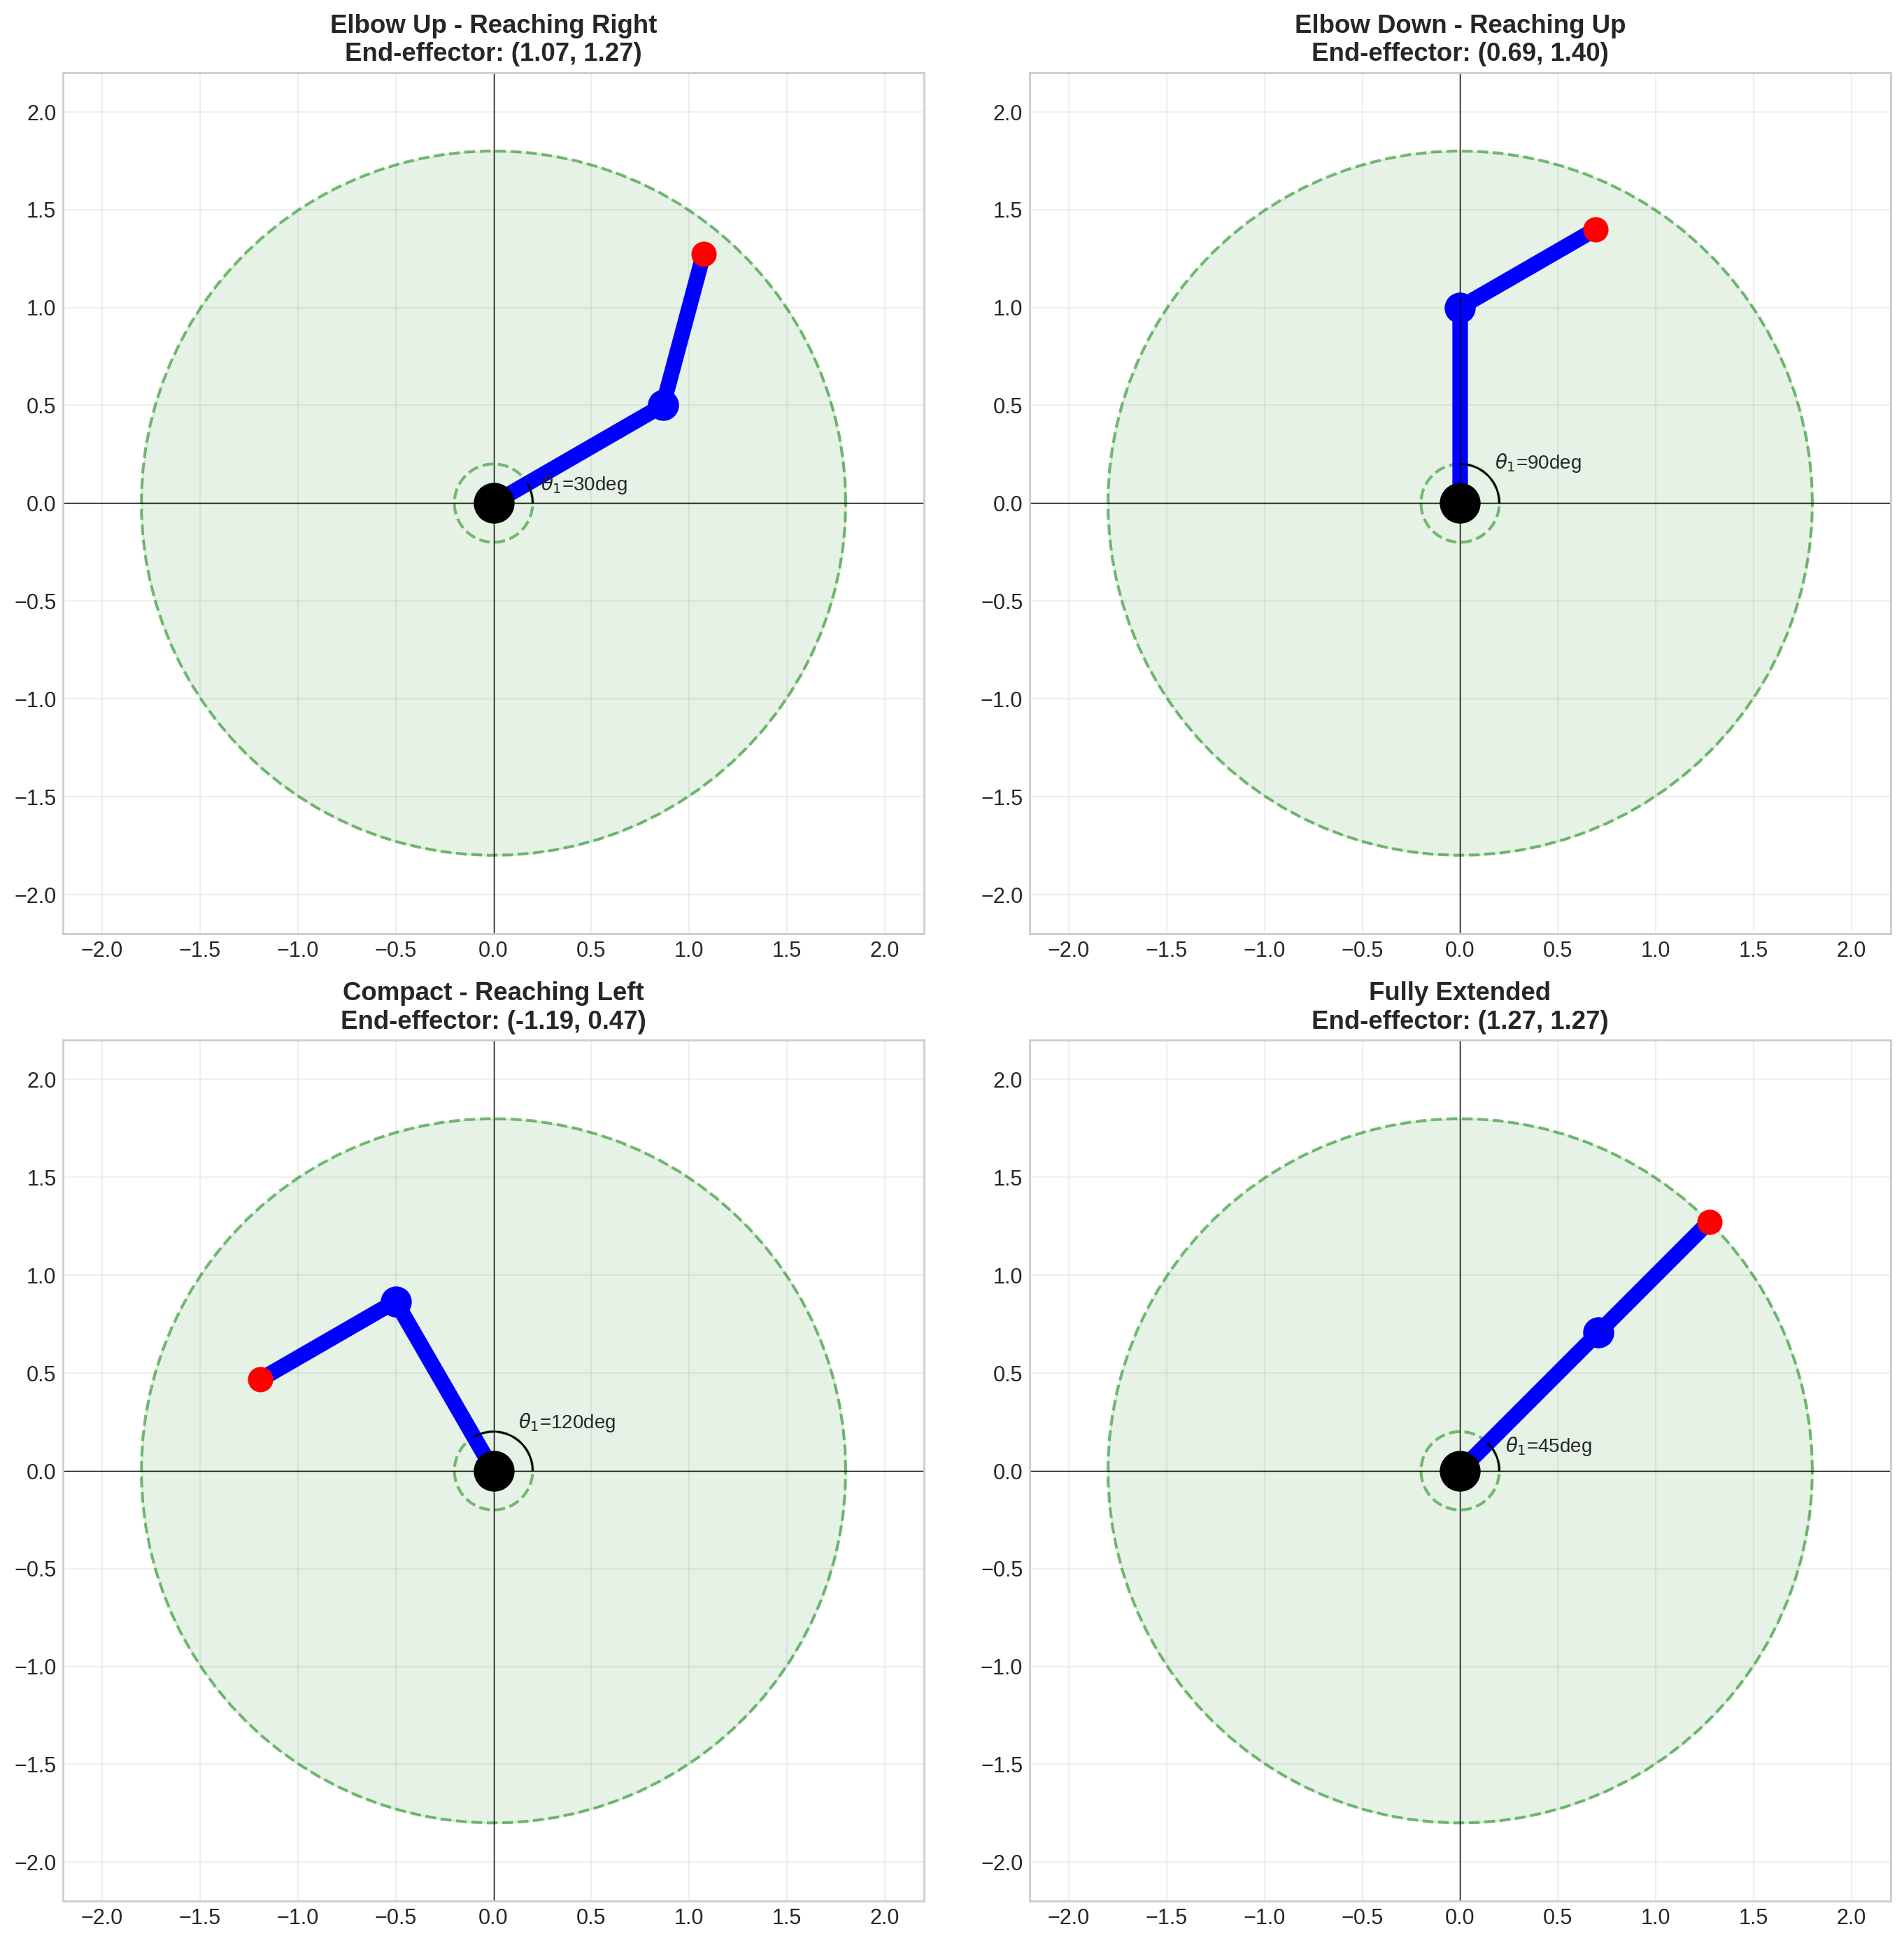

Saved: robot_kinematics_configurations.png


In [4]:
def plot_arm(arm, theta1, theta2, ax=None, show_workspace=True):
    """
    Visualize the robot arm configuration.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get joint positions
    positions = arm.get_joint_positions(theta1, theta2)
    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]
    
    # Plot workspace boundaries
    if show_workspace:
        # Outer boundary (maximum reach)
        theta = np.linspace(0, 2*np.pi, 100)
        outer_r = arm.L1 + arm.L2
        inner_r = abs(arm.L1 - arm.L2)
        ax.plot(outer_r * np.cos(theta), outer_r * np.sin(theta), 
               'g--', alpha=0.5, label='Workspace boundary')
        if inner_r > 0.01:
            ax.plot(inner_r * np.cos(theta), inner_r * np.sin(theta), 
                   'g--', alpha=0.5)
        ax.fill_between(outer_r * np.cos(theta), outer_r * np.sin(theta),
                       alpha=0.1, color='green')
    
    # Plot arm links
    ax.plot(xs, ys, 'b-', linewidth=8, solid_capstyle='round', label='Arm links')
    
    # Plot joints
    ax.plot(xs[0], ys[0], 'ko', markersize=20, label='Base')  # Base
    ax.plot(xs[1], ys[1], 'bo', markersize=15, label='Elbow')  # Elbow
    ax.plot(xs[2], ys[2], 'ro', markersize=12, label='End-effector')  # End-effector
    
    # Add angle annotations
    arc1 = np.linspace(0, theta1, 30)
    ax.plot(0.2 * np.cos(arc1), 0.2 * np.sin(arc1), 'k-', linewidth=1)
    ax.text(0.25 * np.cos(theta1/2), 0.25 * np.sin(theta1/2), 
           f'$\\theta_1$={np.degrees(theta1):.0f}deg', fontsize=10)
    
    return ax

# Plot 1: Multiple arm configurations
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

configurations = [
    (np.pi/6, np.pi/4, 'Elbow Up - Reaching Right'),
    (np.pi/2, -np.pi/3, 'Elbow Down - Reaching Up'),
    (2*np.pi/3, np.pi/2, 'Compact - Reaching Left'),
    (np.pi/4, 0, 'Fully Extended')
]

for ax, (t1, t2, title) in zip(axes.flat, configurations):
    plot_arm(arm, t1, t2, ax=ax)
    x, y = arm.forward_kinematics(t1, t2)
    ax.set_title(f'{title}\nEnd-effector: ({x:.2f}, {y:.2f})', fontweight='bold')
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{NOTEBOOK_DIR}/robot_kinematics_configurations.png', dpi=150, 
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: robot_kinematics_configurations.png")

## 3. Workspace Analysis

The **workspace** is the set of all points reachable by the end-effector. For a 2R arm, the workspace is an annulus (ring shape) defined by:
- Outer radius: $L_1 + L_2$ (arm fully extended)
- Inner radius: $|L_1 - L_2|$ (arm fully folded)

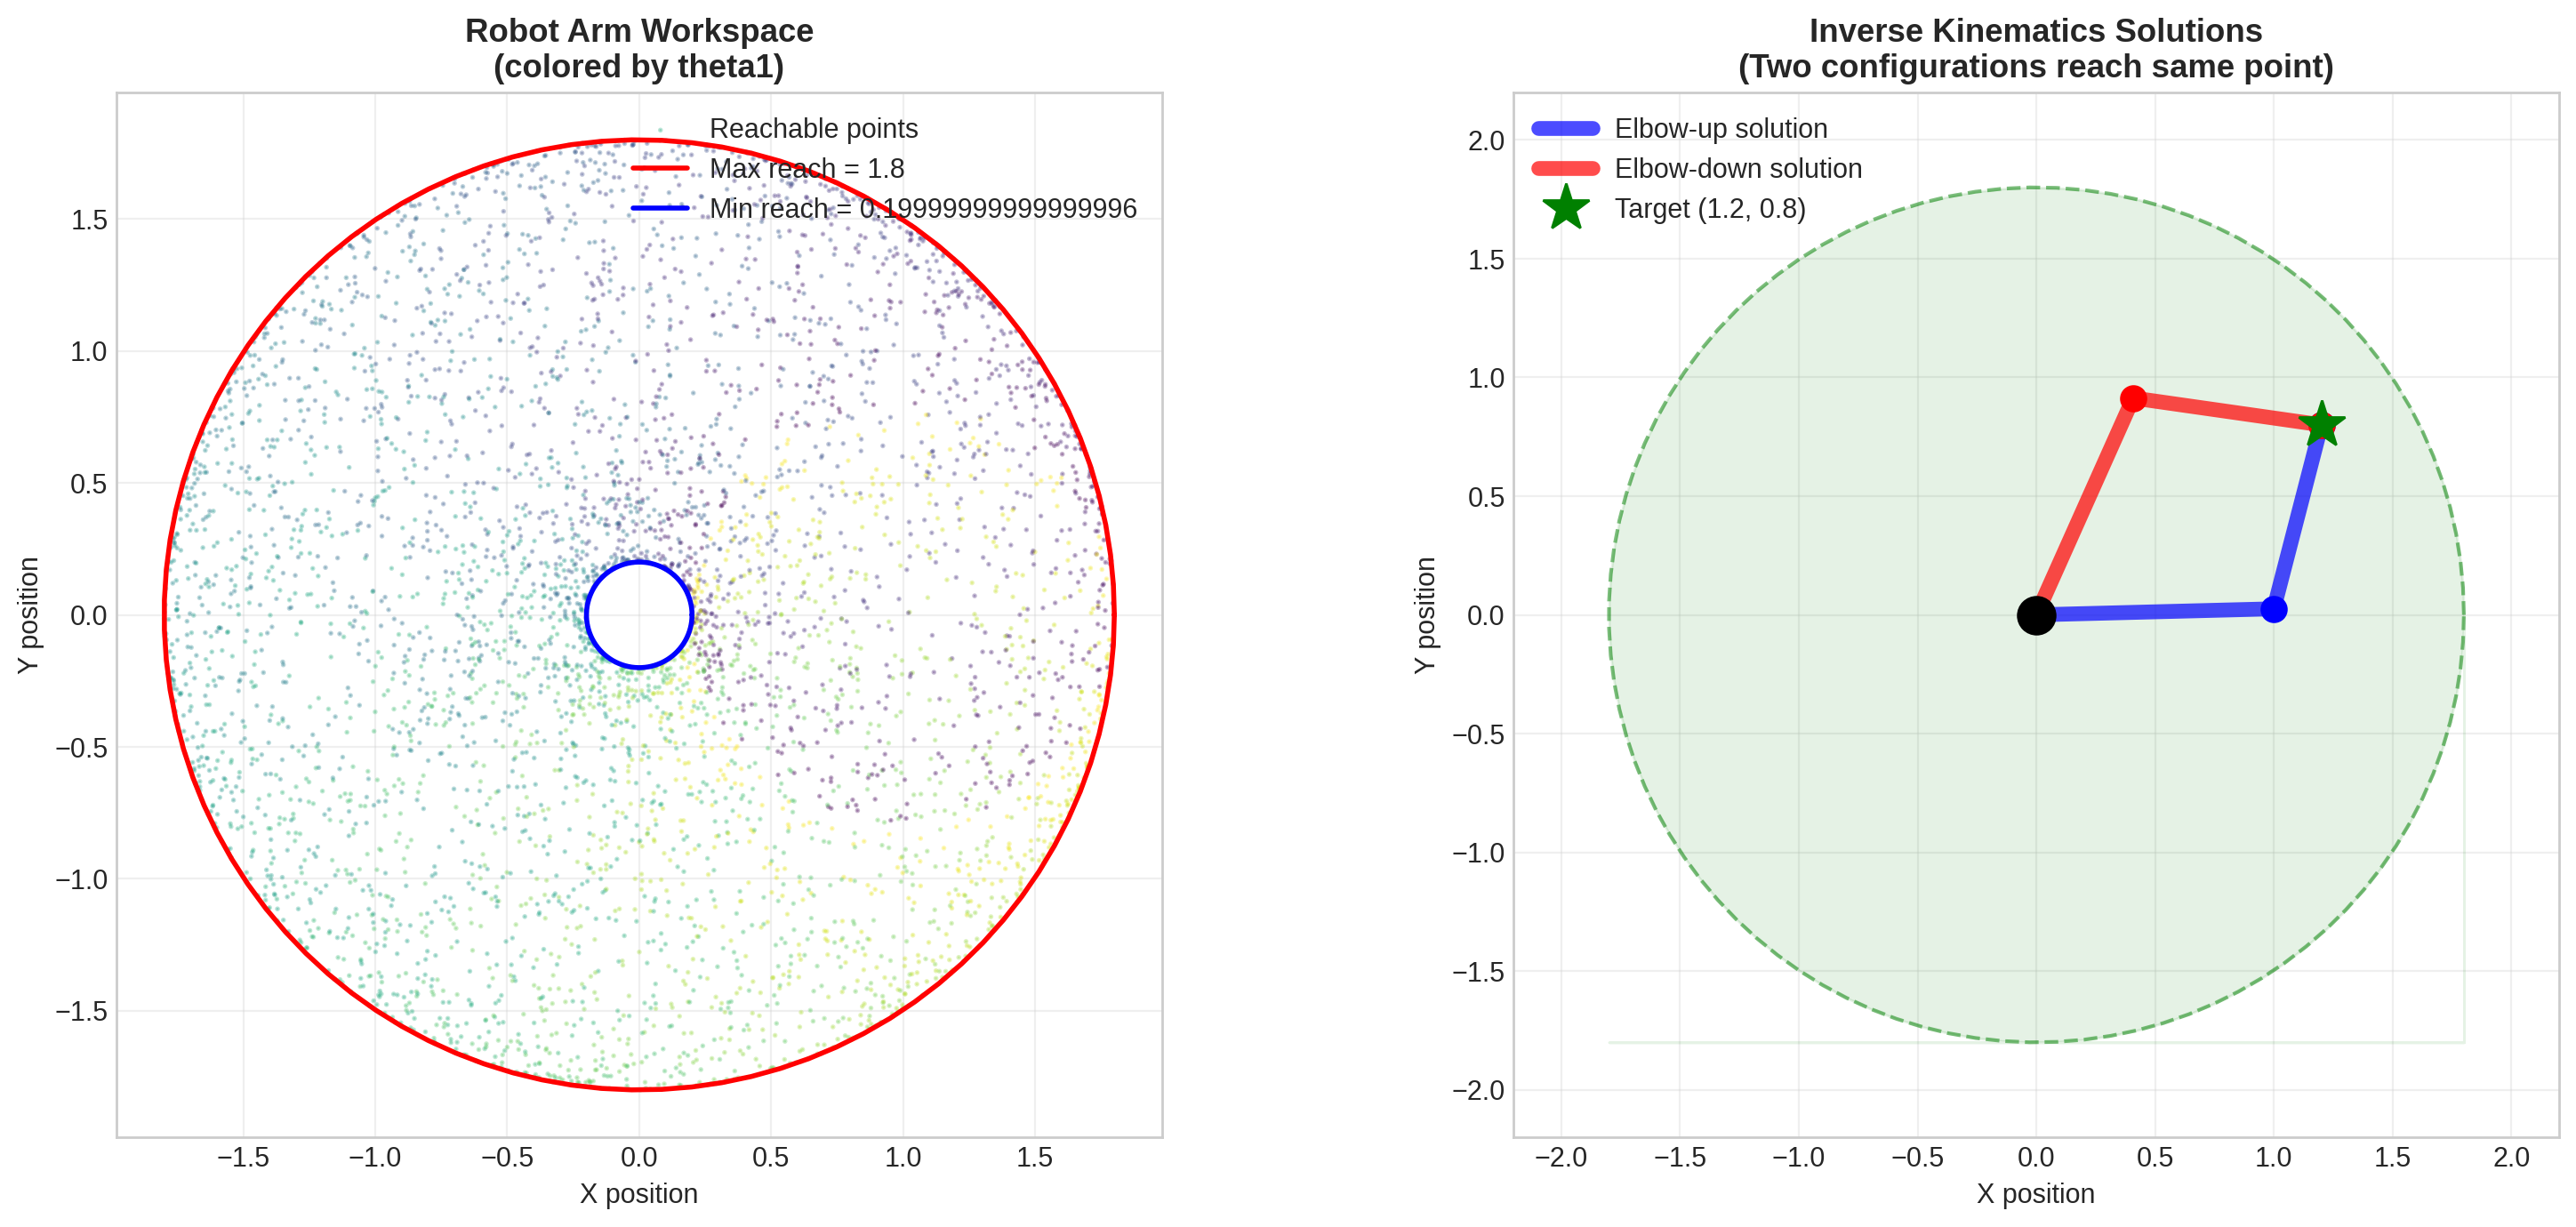

Saved: robot_kinematics_workspace.png


In [5]:
# Plot 2: Workspace visualization with reachability
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Full workspace with sample points
ax1 = axes[0]

# Sample joint space uniformly
n_samples = 5000
theta1_samples = np.random.uniform(0, 2*np.pi, n_samples)
theta2_samples = np.random.uniform(-np.pi, np.pi, n_samples)

# Compute end-effector positions
x_samples = []
y_samples = []
for t1, t2 in zip(theta1_samples, theta2_samples):
    x, y = arm.forward_kinematics(t1, t2)
    x_samples.append(x)
    y_samples.append(y)

ax1.scatter(x_samples, y_samples, c=theta1_samples, cmap='viridis', 
           alpha=0.3, s=1, label='Reachable points')

# Draw workspace boundaries
theta = np.linspace(0, 2*np.pi, 100)
outer_r = arm.L1 + arm.L2
inner_r = abs(arm.L1 - arm.L2)
ax1.plot(outer_r * np.cos(theta), outer_r * np.sin(theta), 'r-', 
        linewidth=2, label=f'Max reach = {outer_r}')
ax1.plot(inner_r * np.cos(theta), inner_r * np.sin(theta), 'b-', 
        linewidth=2, label=f'Min reach = {inner_r}')

ax1.set_xlabel('X position')
ax1.set_ylabel('Y position')
ax1.set_title('Robot Arm Workspace\n(colored by theta1)', fontweight='bold')
ax1.set_aspect('equal')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Inverse kinematics solutions
ax2 = axes[1]

# Target point
target_x, target_y = 1.2, 0.8

# Get both solutions (elbow up and elbow down)
sol_up = arm.inverse_kinematics(target_x, target_y, elbow_up=True)
sol_down = arm.inverse_kinematics(target_x, target_y, elbow_up=False)

# Draw workspace
ax2.fill_between(outer_r * np.cos(theta), -outer_r, outer_r * np.sin(theta),
                alpha=0.1, color='green')
ax2.plot(outer_r * np.cos(theta), outer_r * np.sin(theta), 'g--', alpha=0.5)

# Plot both solutions
if sol_up:
    positions_up = arm.get_joint_positions(*sol_up)
    xs = [p[0] for p in positions_up]
    ys = [p[1] for p in positions_up]
    ax2.plot(xs, ys, 'b-', linewidth=6, alpha=0.7, label='Elbow-up solution')
    ax2.plot(xs, ys, 'bo', markersize=10)

if sol_down:
    positions_down = arm.get_joint_positions(*sol_down)
    xs = [p[0] for p in positions_down]
    ys = [p[1] for p in positions_down]
    ax2.plot(xs, ys, 'r-', linewidth=6, alpha=0.7, label='Elbow-down solution')
    ax2.plot(xs, ys, 'ro', markersize=10)

# Target point
ax2.plot(target_x, target_y, 'g*', markersize=20, label=f'Target ({target_x}, {target_y})')
ax2.plot(0, 0, 'ko', markersize=15)  # Base

ax2.set_xlabel('X position')
ax2.set_ylabel('Y position')
ax2.set_title('Inverse Kinematics Solutions\n(Two configurations reach same point)', fontweight='bold')
ax2.set_xlim(-2.2, 2.2)
ax2.set_ylim(-2.2, 2.2)
ax2.set_aspect('equal')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{NOTEBOOK_DIR}/robot_kinematics_workspace.png', dpi=150, 
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: robot_kinematics_workspace.png")

## 4. Jacobian and Velocity Control

The **Jacobian matrix** relates joint velocities to end-effector velocities:

$$\begin{bmatrix} \dot{x} \\ \dot{y} \end{bmatrix} = J(\theta_1, \theta_2) \begin{bmatrix} \dot{\theta}_1 \\ \dot{\theta}_2 \end{bmatrix}$$

The determinant of J indicates **manipulability**:
- det(J) = 0: Singularity (arm cannot move in some directions)
- Large det(J): High manipulability (can move freely)

In [6]:
# Compute manipulability across joint space
theta1_grid = np.linspace(0, 2*np.pi, 100)
theta2_grid = np.linspace(-np.pi, np.pi, 100)
T1, T2 = np.meshgrid(theta1_grid, theta2_grid)

# Calculate manipulability (det(J)) for each configuration
manipulability = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        J = arm.jacobian(T1[i, j], T2[i, j])
        manipulability[i, j] = abs(np.linalg.det(J))

print(f"Manipulability range: [{manipulability.min():.4f}, {manipulability.max():.4f}]")
print(f"\nSingularity occurs when theta2 = 0 or pi (arm fully extended or folded)")

Manipulability range: [0.0000, 0.7999]

Singularity occurs when theta2 = 0 or pi (arm fully extended or folded)


In [7]:
# Test Jacobian at a specific configuration
test_t1, test_t2 = np.pi/4, np.pi/3
J = arm.jacobian(test_t1, test_t2)

print(f"Configuration: theta1 = {np.degrees(test_t1):.1f} deg, theta2 = {np.degrees(test_t2):.1f} deg")
print(f"\nJacobian matrix:")
print(f"  [{J[0,0]:8.4f}  {J[0,1]:8.4f}]")
print(f"  [{J[1,0]:8.4f}  {J[1,1]:8.4f}]")
print(f"\nDeterminant (manipulability): {np.linalg.det(J):.4f}")

# If joint velocities are [1, 0.5] rad/s, what is end-effector velocity?
joint_vel = np.array([1.0, 0.5])
ee_vel = J @ joint_vel
print(f"\nIf joint velocities = {joint_vel} rad/s")
print(f"Then end-effector velocity = [{ee_vel[0]:.4f}, {ee_vel[1]:.4f}] m/s")

Configuration: theta1 = 45.0 deg, theta2 = 60.0 deg

Jacobian matrix:
  [ -1.4798   -0.7727]
  [  0.5001   -0.2071]

Determinant (manipulability): 0.6928

If joint velocities = [1.  0.5] rad/s
Then end-effector velocity = [-1.8662, 0.3965] m/s


## 5. Trajectory Planning

For smooth robot motion, we use **trajectory planning**:

1. **Point-to-point**: Move from start to goal in joint space
2. **Straight-line**: Move in a straight line in Cartesian space

We'll use a **5th-order polynomial** for smooth acceleration profiles.

In [8]:
def quintic_polynomial(t, T, q0, qf, v0=0, vf=0, a0=0, af=0):
    """
    5th-order polynomial trajectory.
    
    Smooth trajectory from q0 to qf in time T.
    Velocity and acceleration are zero at start and end.
    
    Parameters:
    - t: current time (0 to T)
    - T: total trajectory time
    - q0, qf: start and end positions
    - v0, vf: start and end velocities
    - a0, af: start and end accelerations
    
    Returns: position, velocity, acceleration at time t
    """
    # Solve for polynomial coefficients
    a0_coef = q0
    a1 = v0
    a2 = a0 / 2
    a3 = (20*(qf - q0) - (8*vf + 12*v0)*T - (3*a0 - af)*T**2) / (2*T**3)
    a4 = (-30*(qf - q0) + (14*vf + 16*v0)*T + (3*a0 - 2*af)*T**2) / (2*T**4)
    a5 = (12*(qf - q0) - 6*(vf + v0)*T + (af - a0)*T**2) / (2*T**5)
    
    # Position
    q = a0_coef + a1*t + a2*t**2 + a3*t**3 + a4*t**4 + a5*t**5
    
    # Velocity
    v = a1 + 2*a2*t + 3*a3*t**2 + 4*a4*t**3 + 5*a5*t**4
    
    # Acceleration
    a = 2*a2 + 6*a3*t + 12*a4*t**2 + 20*a5*t**3
    
    return q, v, a

# Generate a trajectory from one configuration to another
T = 2.0  # 2 seconds total time
t_vals = np.linspace(0, T, 100)

# Start and end configurations
theta1_start, theta2_start = np.pi/6, np.pi/4
theta1_end, theta2_end = 2*np.pi/3, -np.pi/3

# Compute trajectories
theta1_traj = []
theta2_traj = []
theta1_vel = []
theta2_vel = []

for t in t_vals:
    q1, v1, _ = quintic_polynomial(t, T, theta1_start, theta1_end)
    q2, v2, _ = quintic_polynomial(t, T, theta2_start, theta2_end)
    theta1_traj.append(q1)
    theta2_traj.append(q2)
    theta1_vel.append(v1)
    theta2_vel.append(v2)

theta1_traj = np.array(theta1_traj)
theta2_traj = np.array(theta2_traj)

# Compute end-effector path
x_path = []
y_path = []
for t1, t2 in zip(theta1_traj, theta2_traj):
    x, y = arm.forward_kinematics(t1, t2)
    x_path.append(x)
    y_path.append(y)

print(f"Trajectory generated from ({np.degrees(theta1_start):.0f}, {np.degrees(theta2_start):.0f}) deg")
print(f"                       to ({np.degrees(theta1_end):.0f}, {np.degrees(theta2_end):.0f}) deg")
print(f"Duration: {T} seconds, {len(t_vals)} waypoints")

Trajectory generated from (30, 45) deg
                       to (120, -60) deg
Duration: 2.0 seconds, 100 waypoints


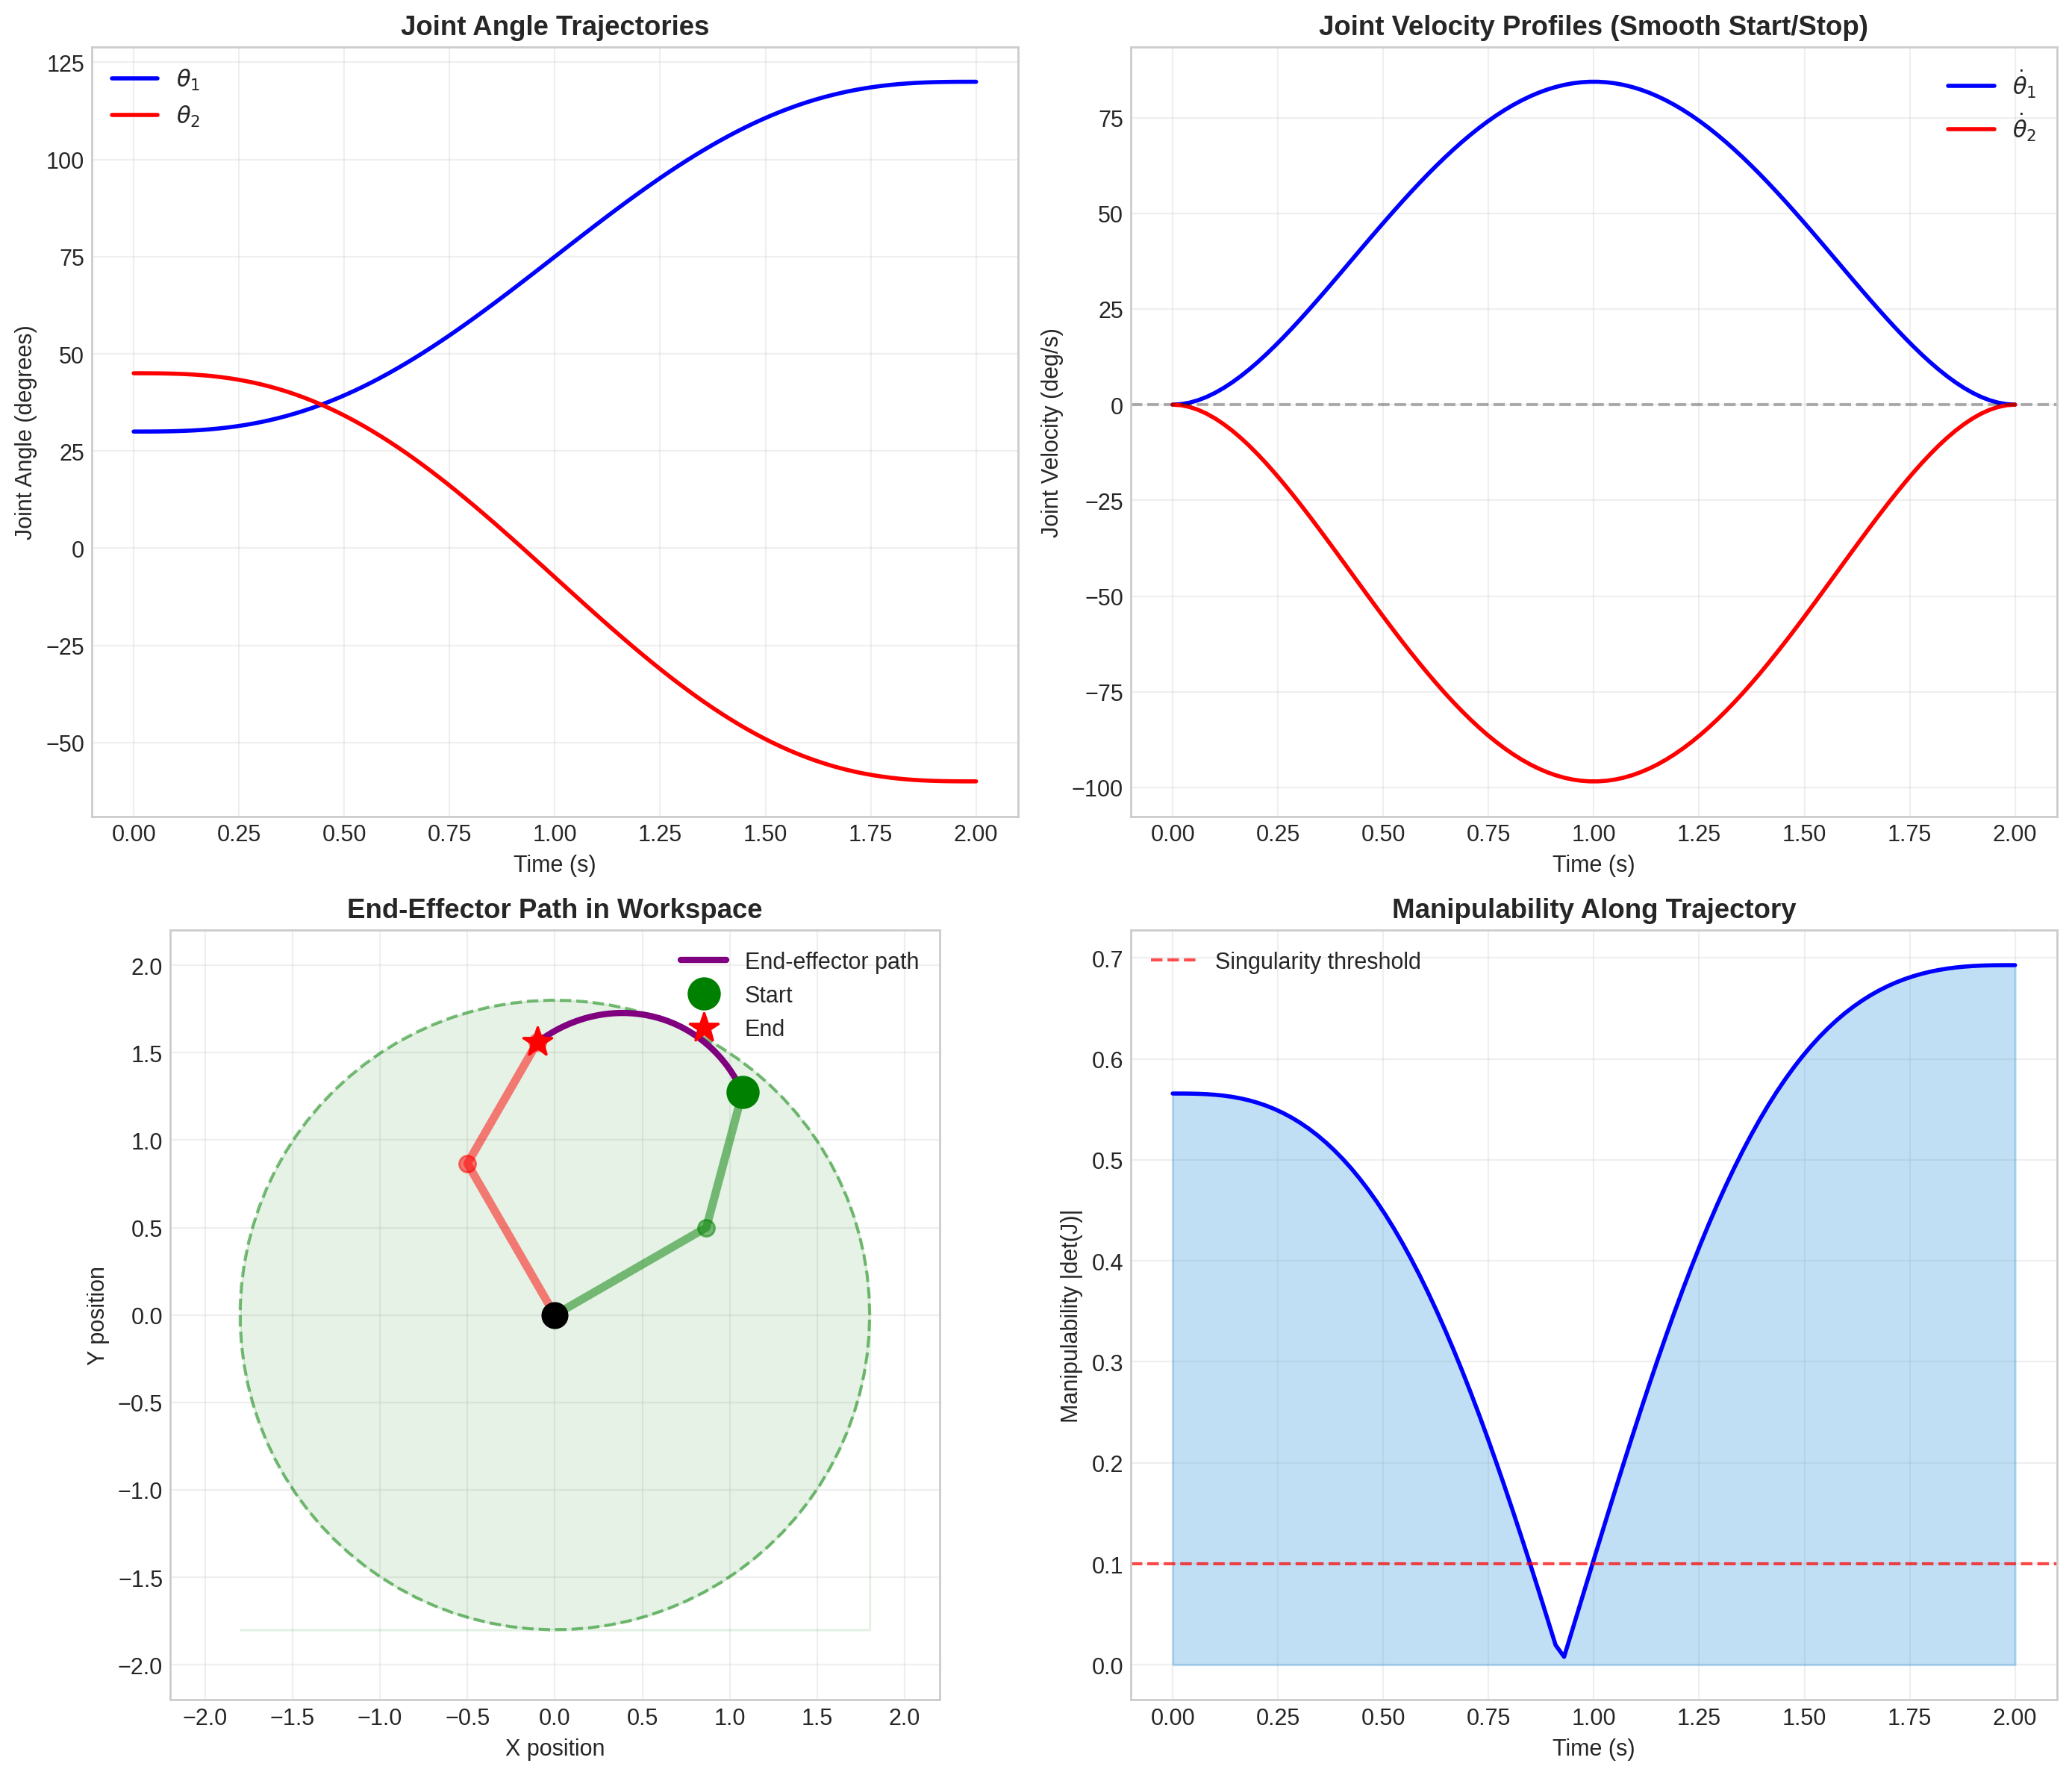

Saved: robot_kinematics_trajectory.png


In [9]:
# Plot 3: Trajectory planning visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top left: Joint trajectories
ax1 = axes[0, 0]
ax1.plot(t_vals, np.degrees(theta1_traj), 'b-', linewidth=2, label='$\\theta_1$')
ax1.plot(t_vals, np.degrees(theta2_traj), 'r-', linewidth=2, label='$\\theta_2$')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Joint Angle (degrees)')
ax1.set_title('Joint Angle Trajectories', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Top right: Joint velocities
ax2 = axes[0, 1]
ax2.plot(t_vals, np.degrees(theta1_vel), 'b-', linewidth=2, label='$\\dot{\\theta}_1$')
ax2.plot(t_vals, np.degrees(theta2_vel), 'r-', linewidth=2, label='$\\dot{\\theta}_2$')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Joint Velocity (deg/s)')
ax2.set_title('Joint Velocity Profiles (Smooth Start/Stop)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom left: End-effector path in workspace
ax3 = axes[1, 0]

# Draw workspace
theta = np.linspace(0, 2*np.pi, 100)
outer_r = arm.L1 + arm.L2
ax3.fill_between(outer_r * np.cos(theta), -outer_r, outer_r * np.sin(theta),
                alpha=0.1, color='green')
ax3.plot(outer_r * np.cos(theta), outer_r * np.sin(theta), 'g--', alpha=0.5)

# Plot path
ax3.plot(x_path, y_path, 'purple', linewidth=3, label='End-effector path')
ax3.plot(x_path[0], y_path[0], 'go', markersize=15, label='Start')
ax3.plot(x_path[-1], y_path[-1], 'r*', markersize=15, label='End')

# Show arm at start and end
for t1, t2, color, alpha in [(theta1_start, theta2_start, 'green', 0.5),
                              (theta1_end, theta2_end, 'red', 0.5)]:
    positions = arm.get_joint_positions(t1, t2)
    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]
    ax3.plot(xs, ys, '-', color=color, linewidth=4, alpha=alpha)
    ax3.plot(xs, ys, 'o', color=color, markersize=8, alpha=alpha)

ax3.plot(0, 0, 'ko', markersize=12)
ax3.set_xlabel('X position')
ax3.set_ylabel('Y position')
ax3.set_title('End-Effector Path in Workspace', fontweight='bold')
ax3.set_aspect('equal')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-2.2, 2.2)
ax3.set_ylim(-2.2, 2.2)

# Bottom right: Manipulability along trajectory
ax4 = axes[1, 1]

manipulability_traj = []
for t1, t2 in zip(theta1_traj, theta2_traj):
    J = arm.jacobian(t1, t2)
    manipulability_traj.append(abs(np.linalg.det(J)))

ax4.fill_between(t_vals, manipulability_traj, alpha=0.3, color='#3498db')
ax4.plot(t_vals, manipulability_traj, 'b-', linewidth=2)
ax4.axhline(y=0.1, color='r', linestyle='--', label='Singularity threshold', alpha=0.7)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Manipulability |det(J)|')
ax4.set_title('Manipulability Along Trajectory', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{NOTEBOOK_DIR}/robot_kinematics_trajectory.png', dpi=150, 
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: robot_kinematics_trajectory.png")

## 6. Manipulability Analysis

Let's visualize how manipulability varies across the joint space and what it means for robot control.

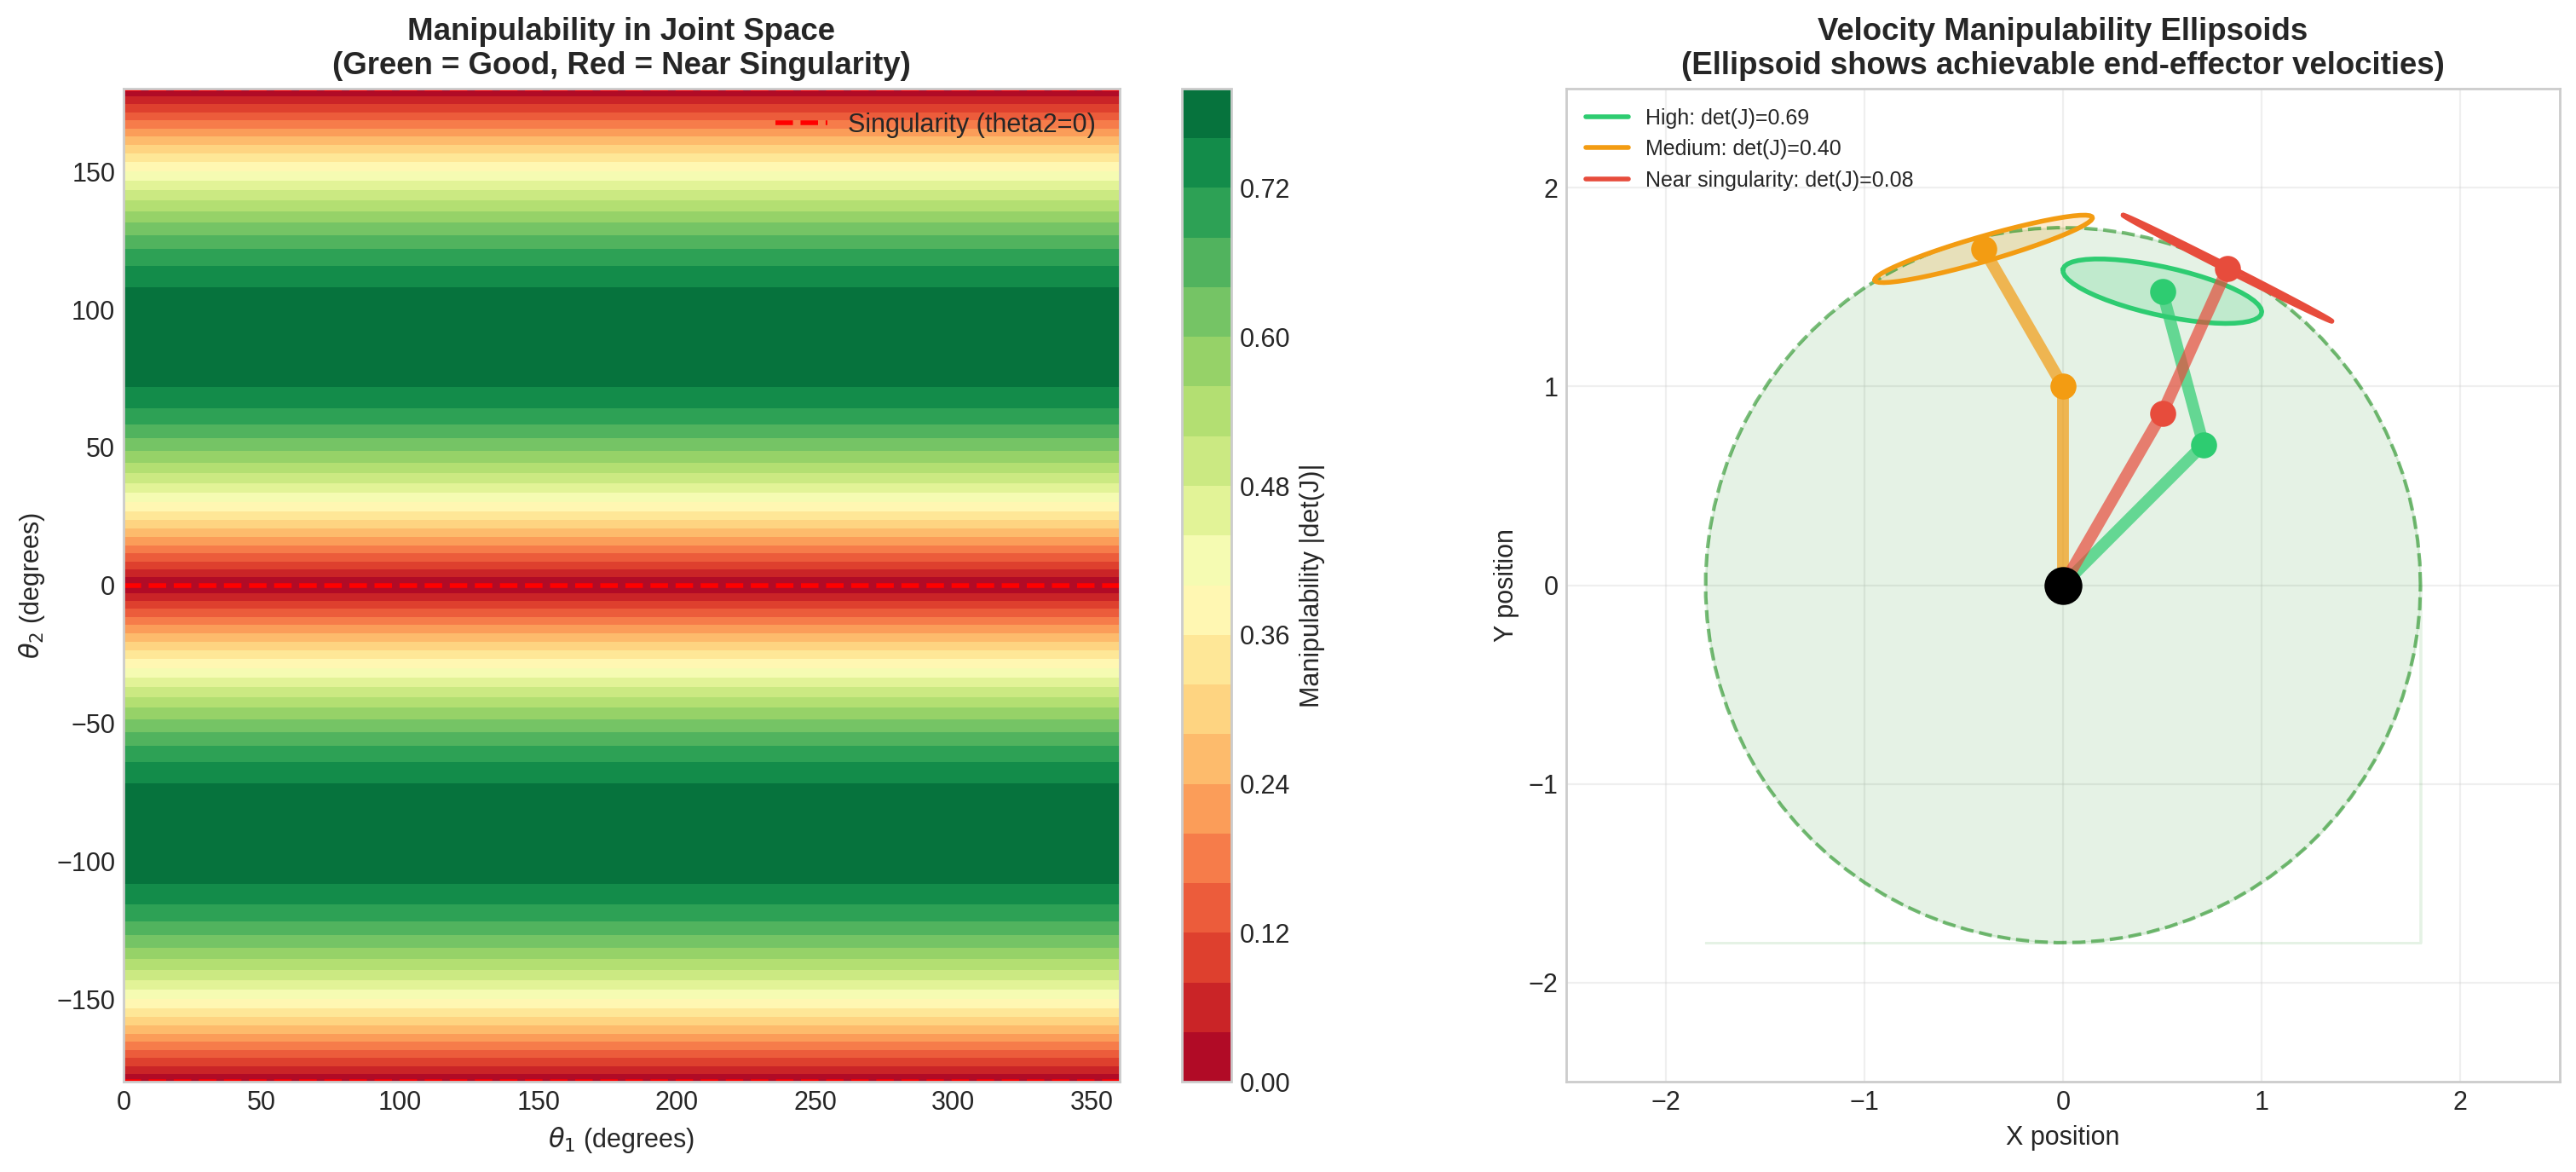

Saved: robot_kinematics_manipulability.png


In [10]:
# Plot 4: Manipulability analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Manipulability heatmap in joint space
ax1 = axes[0]
im = ax1.contourf(np.degrees(T1), np.degrees(T2), manipulability, levels=20, cmap='RdYlGn')
plt.colorbar(im, ax=ax1, label='Manipulability |det(J)|')

# Mark singularities
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Singularity (theta2=0)')
ax1.axhline(y=180, color='red', linestyle='--', linewidth=2)
ax1.axhline(y=-180, color='red', linestyle='--', linewidth=2)

ax1.set_xlabel('$\\theta_1$ (degrees)')
ax1.set_ylabel('$\\theta_2$ (degrees)')
ax1.set_title('Manipulability in Joint Space\n(Green = Good, Red = Near Singularity)', fontweight='bold')
ax1.legend(loc='upper right')

# Right: Manipulability ellipsoids at different configurations
ax2 = axes[1]

# Draw workspace
theta = np.linspace(0, 2*np.pi, 100)
outer_r = arm.L1 + arm.L2
ax2.fill_between(outer_r * np.cos(theta), -outer_r, outer_r * np.sin(theta),
                alpha=0.1, color='green')
ax2.plot(outer_r * np.cos(theta), outer_r * np.sin(theta), 'g--', alpha=0.5)

# Show manipulability ellipsoids at several configurations
configs = [
    (np.pi/4, np.pi/3, 'High'),
    (np.pi/2, np.pi/6, 'Medium'),
    (np.pi/3, 0.1, 'Near singularity')
]

colors = ['#2ecc71', '#f39c12', '#e74c3c']

for (t1, t2, label), color in zip(configs, colors):
    # Draw arm
    positions = arm.get_joint_positions(t1, t2)
    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]
    ax2.plot(xs, ys, '-', color=color, linewidth=5, alpha=0.7)
    ax2.plot(xs[1:], ys[1:], 'o', color=color, markersize=10)
    
    # Compute and draw velocity ellipsoid
    J = arm.jacobian(t1, t2)
    x_ee, y_ee = arm.forward_kinematics(t1, t2)
    
    # SVD of Jacobian gives ellipsoid axes
    U, s, Vt = np.linalg.svd(J)
    
    # Draw ellipsoid (scaled for visibility)
    ellipse_theta = np.linspace(0, 2*np.pi, 50)
    scale = 0.3
    ellipse = scale * np.array([s[0] * np.cos(ellipse_theta), 
                                 s[1] * np.sin(ellipse_theta)])
    ellipse_rotated = U @ ellipse
    ax2.plot(x_ee + ellipse_rotated[0], y_ee + ellipse_rotated[1], 
            color=color, linewidth=2, label=f'{label}: det(J)={np.linalg.det(J):.2f}')
    ax2.fill(x_ee + ellipse_rotated[0], y_ee + ellipse_rotated[1], 
            color=color, alpha=0.2)

ax2.plot(0, 0, 'ko', markersize=15)
ax2.set_xlabel('X position')
ax2.set_ylabel('Y position')
ax2.set_title('Velocity Manipulability Ellipsoids\n(Ellipsoid shows achievable end-effector velocities)', fontweight='bold')
ax2.set_aspect('equal')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.savefig(f'{NOTEBOOK_DIR}/robot_kinematics_manipulability.png', dpi=150, 
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: robot_kinematics_manipulability.png")

## Summary

This notebook covered the essential concepts of robot arm kinematics:

1. **Forward Kinematics**: Computing end-effector position from joint angles using trigonometry

2. **Inverse Kinematics**: Finding joint angles to reach a target position (multiple solutions exist)

3. **Workspace Analysis**: The set of all reachable points forms an annulus for a 2R arm

4. **Jacobian Matrix**: Relates joint velocities to end-effector velocities; its determinant indicates manipulability

5. **Trajectory Planning**: Using polynomial interpolation for smooth motion

6. **Manipulability**: Understanding where the robot can move easily (high manipulability) vs. near singularities (low manipulability)

### Key Equations

**Forward Kinematics:**
$$x = L_1 \cos\theta_1 + L_2 \cos(\theta_1 + \theta_2)$$
$$y = L_1 \sin\theta_1 + L_2 \sin(\theta_1 + \theta_2)$$

**Jacobian:**
$$J = \begin{bmatrix} -L_1 s_1 - L_2 s_{12} & -L_2 s_{12} \\ L_1 c_1 + L_2 c_{12} & L_2 c_{12} \end{bmatrix}$$

Where $s_1 = \sin\theta_1$, $c_1 = \cos\theta_1$, $s_{12} = \sin(\theta_1+\theta_2)$, $c_{12} = \cos(\theta_1+\theta_2)$

In [11]:
print("\n" + "=" * 70)
print("ROBOT KINEMATICS NOTEBOOK COMPLETE")
print("=" * 70)

print("""
Plots generated:
  1. robot_kinematics_configurations.png - Four arm configurations
  2. robot_kinematics_workspace.png - Workspace and IK solutions
  3. robot_kinematics_trajectory.png - Trajectory planning
  4. robot_kinematics_manipulability.png - Manipulability analysis

Key concepts demonstrated:
  - 2-link planar robot arm model
  - Forward and inverse kinematics
  - Jacobian matrix and velocity control
  - 5th-order polynomial trajectory planning
  - Manipulability ellipsoids and singularities
""")


ROBOT KINEMATICS NOTEBOOK COMPLETE

Plots generated:
  1. robot_kinematics_configurations.png - Four arm configurations
  2. robot_kinematics_workspace.png - Workspace and IK solutions
  3. robot_kinematics_trajectory.png - Trajectory planning
  4. robot_kinematics_manipulability.png - Manipulability analysis

Key concepts demonstrated:
  - 2-link planar robot arm model
  - Forward and inverse kinematics
  - Jacobian matrix and velocity control
  - 5th-order polynomial trajectory planning
  - Manipulability ellipsoids and singularities

